In [7]:
sky_merger_sig_csv = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/sky_merger/sky_after6_ckpt_62-63s_d64_s64_l4/plots/sky_loc_results.csv'
sky_merger_bkg_csv = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/00_AI4GW_TALK/sky_merger_bkg/plots/sky_loc_results.csv'

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

df = pd.read_csv(sky_merger_sig_csv)
print(f'{len(df):,} events loaded')
df.head(3)

20,000 events loaded


,dec_true,phi_true,dec_pred,phi_pred,dec_residual,phi_residual,cos_theta_true,cos_theta_pred,ring_distance,angular_error_deg,snr
0,0.127017,-2.839487,0.901864,-2.838835,0.774847,0.000652,-0.553169,-0.668859,0.115689,44.395493,12.739459
1,-0.306375,-1.609804,0.041021,-1.264393,0.347396,0.345412,0.639768,0.718059,0.078291,27.871746,16.838099
2,-0.374419,-2.756303,0.660436,2.597468,1.034855,5.353771,-0.238407,-0.977318,0.738911,77.561110,13.309256


## cos θ: True vs Predicted
Bin true cos θ and show the **mean** prediction ± **68% band** (q16–q84).

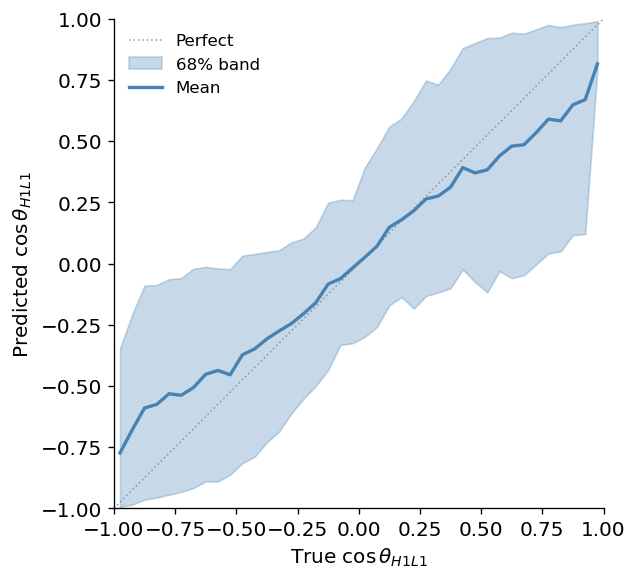

In [9]:
cos_true = df['cos_theta_true'].values
cos_pred = df['cos_theta_pred'].values

bins    = np.linspace(-1.0, 1.0, 41)
centers = 0.5 * (bins[:-1] + bins[1:])

mean_p = np.full(len(centers), np.nan)
q16    = np.full(len(centers), np.nan)
q84    = np.full(len(centers), np.nan)

for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mask = (cos_true >= lo) & (cos_true < hi)
    if mask.sum() < 2:
        continue
    p = cos_pred[mask]
    mean_p[i] = np.mean(p)
    q16[i]    = np.percentile(p, 16)
    q84[i]    = np.percentile(p, 84)

valid = ~np.isnan(mean_p)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([-1, 1], [-1, 1], color='gray', lw=1.0, ls=':', alpha=0.7, label='Perfect')
ax.fill_between(centers[valid], q16[valid], q84[valid],
                alpha=0.30, color='steelblue', label='68% band')
ax.plot(centers[valid], mean_p[valid], color='steelblue', lw=2.0, label='Mean')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal')
ax.set_xlabel(r'True $\cos\theta_{H1L1}$')
ax.set_ylabel(r'Predicted $\cos\theta_{H1L1}$')
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

## Sky Map: All Events
Mollweide projection. True positions colored by angular error; predicted positions in red.

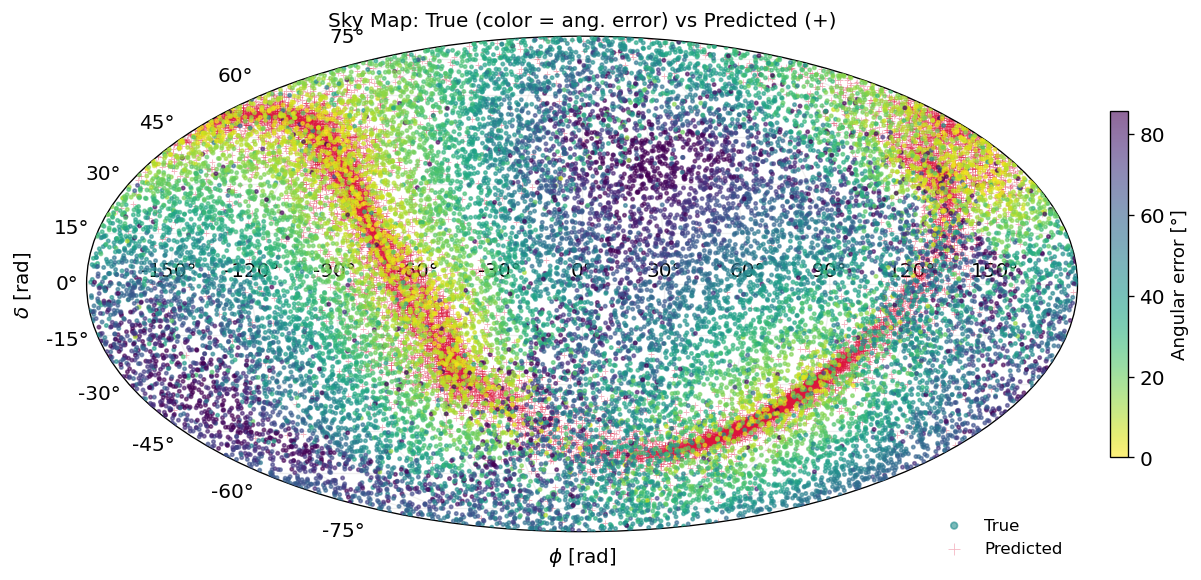

In [10]:
dec_true  = df['dec_true'].values
phi_true  = df['phi_true'].values
dec_pred  = df['dec_pred'].values
phi_pred  = df['phi_pred'].values
ang_err   = df['angular_error_deg'].values
ring_dist = df['ring_distance'].values
snr       = df['snr'].values

# Mollweide needs phi in [-pi, pi]
phi_true_w = (phi_true + np.pi) % (2 * np.pi) - np.pi
phi_pred_w = (phi_pred + np.pi) % (2 * np.pi) - np.pi

fig = plt.figure(figsize=(14, 5))
ax  = fig.add_subplot(111, projection='mollweide')

sc = ax.scatter(phi_true_w, dec_true, c=ang_err, cmap='viridis_r',
                s=4, alpha=0.6, vmin=0, vmax=np.percentile(ang_err, 95),
                zorder=3, label='True')
ax.scatter(phi_pred_w, dec_pred, c='crimson', marker='+',
           s=12, alpha=0.3, linewidths=0.5, zorder=2, label='Predicted')

cb = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cb.set_label('Angular error [°]', fontsize=11)
ax.set_xlabel(r'$\phi$ [rad]', labelpad=8)
ax.set_ylabel(r'$\delta$ [rad]', labelpad=8)
ax.set_title('Sky Map: True (color = ang. error) vs Predicted (+)', fontsize=12)
ax.legend(frameon=False, fontsize=10, loc='lower right',
          markerscale=2, bbox_to_anchor=(1.0, -0.08))
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## Single-Event Sky Map: Ring Only
- **Ring** (dashed blue): great-circle locus where `u · ĤL = cos θ_pred` — the H1–L1 time-delay degeneracy ring
- Red ★ = true position

Event #7162  SNR=14.2  ang_err=39.9°  ring_dist=0.095


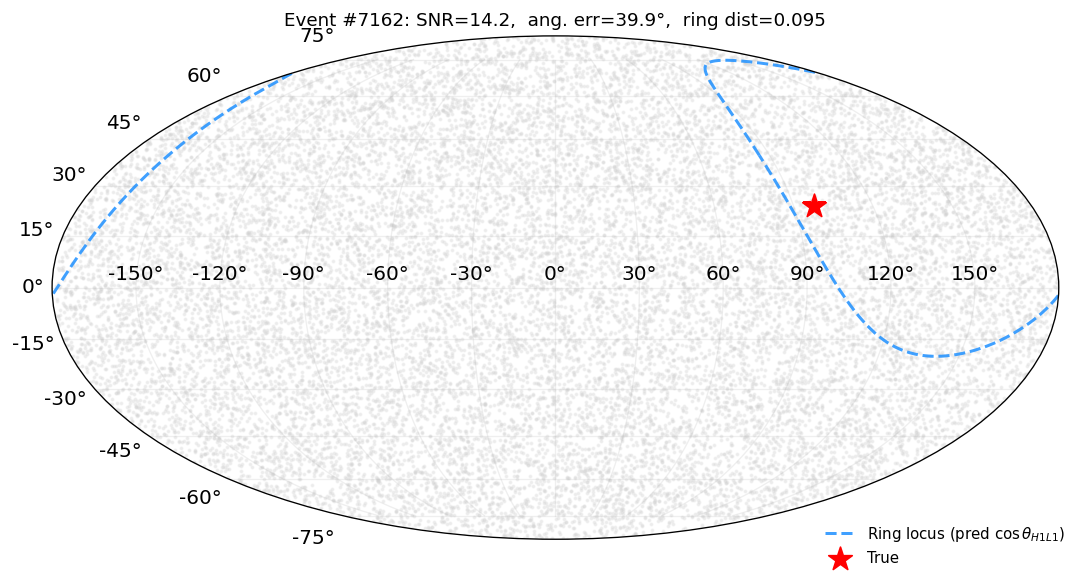

In [11]:
# ── geometry helpers ──────────────────────────────────────────────────────────────────────────────
_H1L1 = np.array([0.6953014731407166, -0.5535351634025574, -0.4584263563156128])

def ring_locus(cos_theta, n=800):
    b = _H1L1
    ref = np.array([1., 0., 0.]) if abs(b[0]) < 0.9 else np.array([0., 1., 0.])
    e1 = ref - b * (ref @ b); e1 /= np.linalg.norm(e1)
    e2 = np.cross(b, e1);     e2 /= np.linalg.norm(e2)
    sin_a = np.sqrt(max(0.0, 1.0 - cos_theta**2))
    t = np.linspace(0, 2*np.pi, n)
    pts = cos_theta * b[:, None] + sin_a * (np.outer(e1, np.cos(t)) + np.outer(e2, np.sin(t)))
    return np.arcsin(np.clip(pts[2], -1, 1)), np.arctan2(pts[1], pts[0])

def plot_curve_wrapped(ax, decs, phis, **kwargs):
    phis_w = (phis + np.pi) % (2*np.pi) - np.pi
    jumps  = list(np.where(np.abs(np.diff(phis_w)) > np.pi)[0] + 1)
    segs   = np.split(np.column_stack([phis_w, decs]), jumps)
    lbl    = kwargs.pop('label', None)
    for k, seg in enumerate(segs):
        ax.plot(seg[:, 0], seg[:, 1], label=(lbl if k == 0 else None), **kwargs)

# ── pick event closest to median angular error ───────────────────────────────────────────────
TARGET_ANG_ERR = np.median(ang_err)   # change to any value in degrees
idx = np.argmin(np.abs(ang_err - TARGET_ANG_ERR))
print(f'Event #{idx}  SNR={snr[idx]:.1f}  ang_err={ang_err[idx]:.1f}°  ring_dist={ring_dist[idx]:.3f}')

ring_d, ring_p = ring_locus(df['cos_theta_pred'].iloc[idx])

fig = plt.figure(figsize=(13, 5))
ax  = fig.add_subplot(111, projection='mollweide')
ax.scatter(phi_true_w, dec_true, c='lightgray', s=2, alpha=0.25, zorder=1)
plot_curve_wrapped(ax, ring_d, ring_p,
                   color='dodgerblue', lw=1.8, ls='--', alpha=0.85,
                   label=r'Ring locus (pred $\cos\theta_{H1L1}$)')
ax.scatter((phi_true[idx] + np.pi) % (2*np.pi) - np.pi, dec_true[idx],
           marker='*', s=220, c='red', linewidths=1.0, zorder=6, label='True')
ax.set_title(f'Event #{idx}: SNR={snr[idx]:.1f},  ang. err={ang_err[idx]:.1f}°,  '
             f'ring dist={ring_dist[idx]:.3f}', fontsize=11)
ax.legend(frameon=False, fontsize=9, loc='lower right', bbox_to_anchor=(1.02, -0.08))
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## GIF: 50 Events — Ring + True Position (1 s/frame)

Rendering 50 frames...


Saved → /n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/sky_merger/ring_events.gif


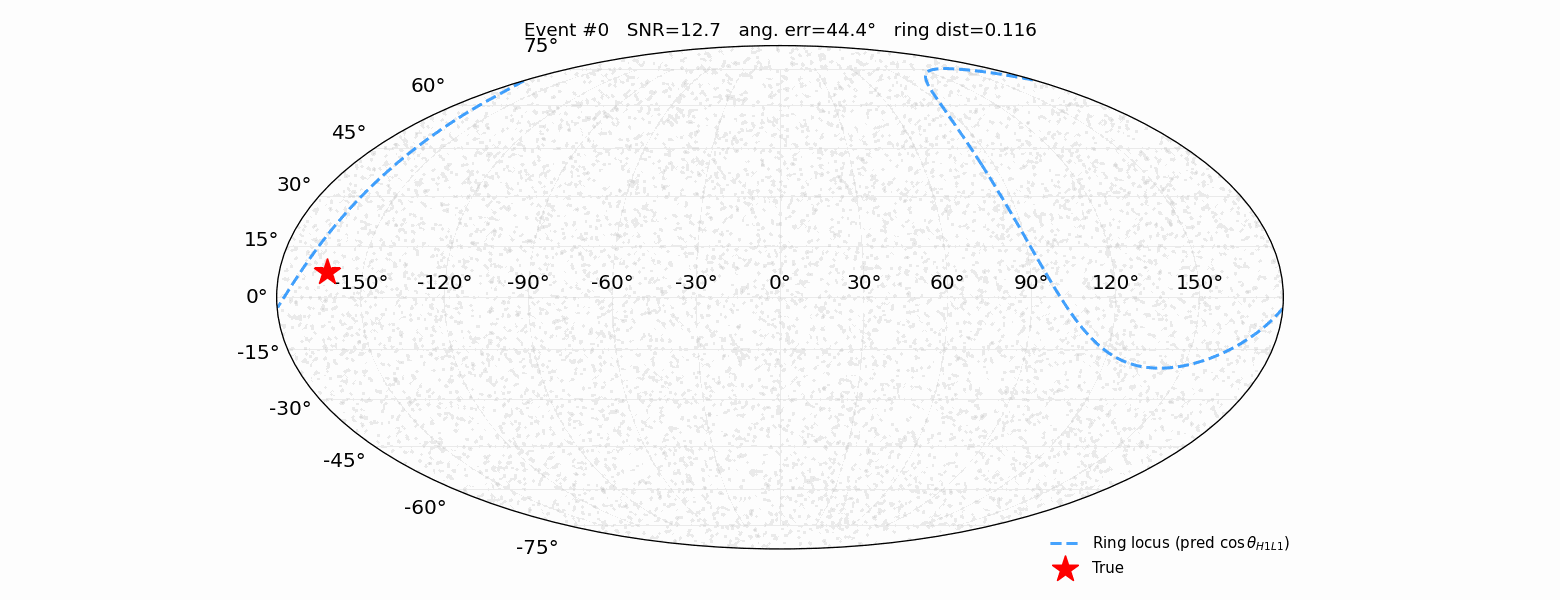

In [14]:
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display

GIF_PATH   = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/sky_merger/ring_events.gif'
N_EVENTS   = 50
DURATION_S = 1        # seconds per frame

# sample evenly across dataset for variety
event_idx = np.linspace(0, len(df) - 1, N_EVENTS, dtype=int)

# pre-compute all rings
rings = [ring_locus(df['cos_theta_pred'].iloc[i]) for i in event_idx]

print('Rendering 50 frames...')
pil_frames = []
for k, i in enumerate(event_idx):
    rd, rp = rings[k]

    fig = plt.figure(figsize=(13, 5))
    ax  = fig.add_subplot(111, projection='mollweide')
    ax.scatter(phi_true_w, dec_true, c='lightgray', s=2, alpha=0.2, zorder=1)
    plot_curve_wrapped(ax, rd, rp,
                       color='dodgerblue', lw=1.8, ls='--', alpha=0.85,
                       label=r'Ring locus (pred $\cos\theta_{H1L1}$)')
    ax.scatter((phi_true[i] + np.pi) % (2*np.pi) - np.pi, dec_true[i],
               marker='*', s=260, c='red', linewidths=1.0, zorder=6, label='True')
    ax.set_title(
        f'Event #{i}   SNR={snr[i]:.1f}   '
        f'ang. err={ang_err[i]:.1f}°   ring dist={ring_dist[i]:.3f}',
        fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc='lower right', bbox_to_anchor=(1.02, -0.08))
    ax.grid(True, alpha=0.2)
    fig.tight_layout()

    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=fig.dpi)
    buf.seek(0)
    pil_frames.append(PILImage.open(buf).copy())
    plt.close(fig)

pil_frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=pil_frames[1:],
    duration=DURATION_S * 1000,
    loop=0,
)
print(f'Saved → {GIF_PATH}')
display(IPImage(filename=GIF_PATH))